In [6]:
import numpy as np

In [8]:
from sklearn.linear_model import LinearRegression
import numpy as np

df = df.sort_values("date").reset_index(drop=True)
df["month_index"] = np.arange(len(df))

X = df[["month_index"]]
y = df["price_uah"]

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [1]:
import pandas as pd

df = pd.read_csv("../data/gasoline_prices_ukraine.csv")
df.head()

,date,price_uah
0,2022-01,31.45
1,2022-02,33.10
2,2022-03,34.20
3,2022-04,32.80
4,2022-05,39.50


In [2]:
df["date"] = pd.to_datetime(df["date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       48 non-null     datetime64[us]
 1   price_uah  48 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 900.0 bytes


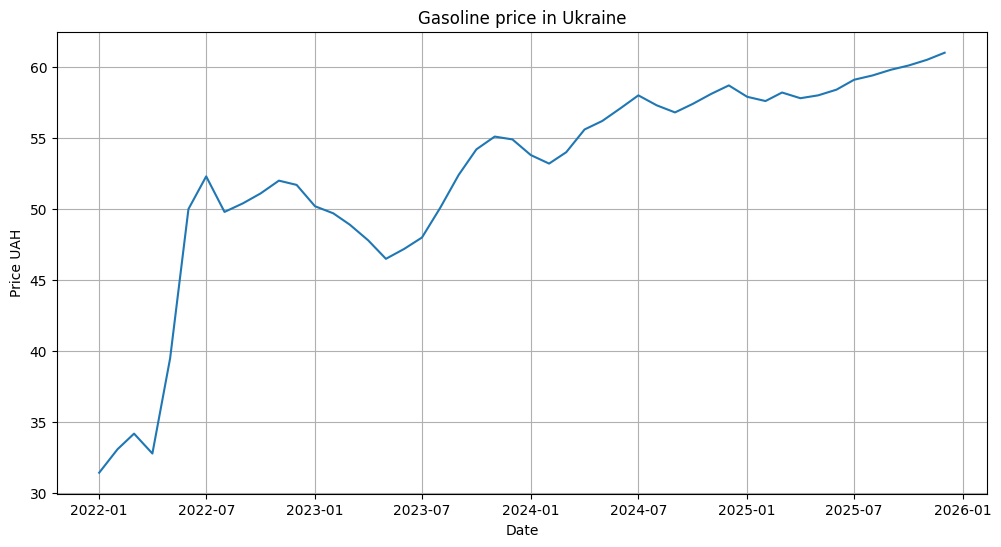

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df["date"], df["price_uah"])
plt.title("Gasoline price in Ukraine")
plt.xlabel("Date")
plt.ylabel("Price UAH")
plt.grid(True)
plt.show()

In [12]:
future_dates = pd.date_range(start="2026-01-01", end="2026-12-01", freq="MS")
future_index = np.arange(len(df), len(df) + len(future_dates))

future_df = pd.DataFrame({
    "date": future_dates,
    "month_index": future_index
})

future_df["predicted_price_uah"] = model.predict(future_df[["month_index"]])
future_df

,date,month_index,predicted_price_uah
0,2026-01-01,48,63.534353
1,2026-02-01,49,63.986988
2,2026-03-01,50,64.439623
3,2026-04-01,51,64.892258
4,2026-05-01,52,65.344893
5,2026-06-01,53,65.797529
6,2026-07-01,54,66.250164
7,2026-08-01,55,66.702799
8,2026-09-01,56,67.155434
9,2026-10-01,57,67.608069


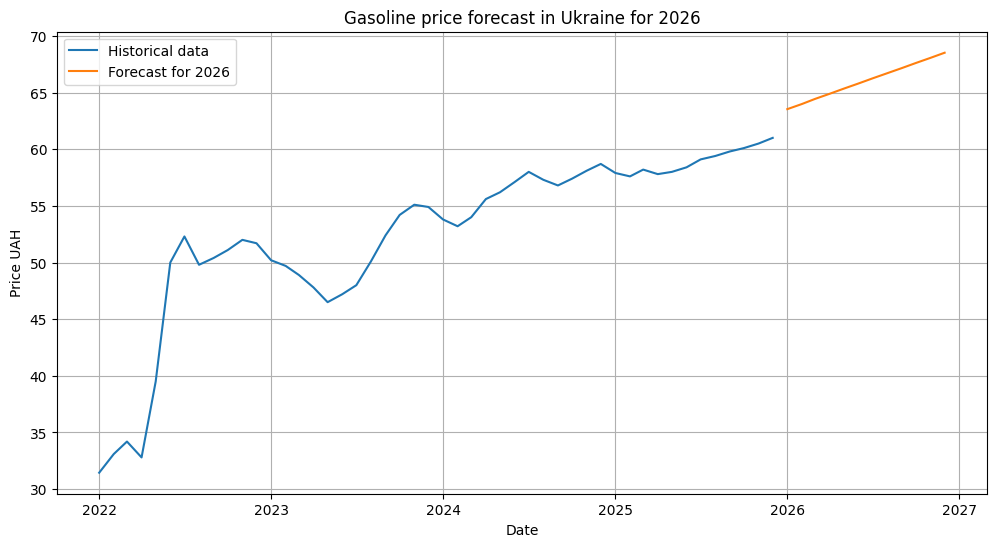

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(df["date"], df["price_uah"], label="Historical data")
plt.plot(future_df["date"], future_df["predicted_price_uah"], label="Forecast for 2026")

plt.title("Gasoline price forecast in Ukraine for 2026")
plt.xlabel("Date")
plt.ylabel("Price UAH")

plt.legend()
plt.grid(True)

plt.savefig("../outputs/forecast_plot.png")
plt.show()

In [15]:
future_df.to_csv("../outputs/gasoline_forecast_2026.csv", index=False)